In [1]:
from galpy.potential import PlummerPotential, NFWPotential
from galpy.df import isotropicPlummerdf
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from ezfalcon.tools import galpydfsampler
from ezfalcon.simulation import Sim
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [2]:
progpot = PlummerPotential(amp=1e10*u.Msun, b=0.5*u.kpc)
df = isotropicPlummerdf(pot=progpot)
pos, vel, masses = galpydfsampler(df, n=10_000, m_total=1e10, center_pos=[8,0,0], center_vel=[0,0.066,0])

In [3]:
sim = Sim()
sim.add_particles('stars', pos, vel, masses)

host_pot = NFWPotential(amp=1e13*u.Msun, a=20*u.kpc)
sim.add_external_pot(host_pot)

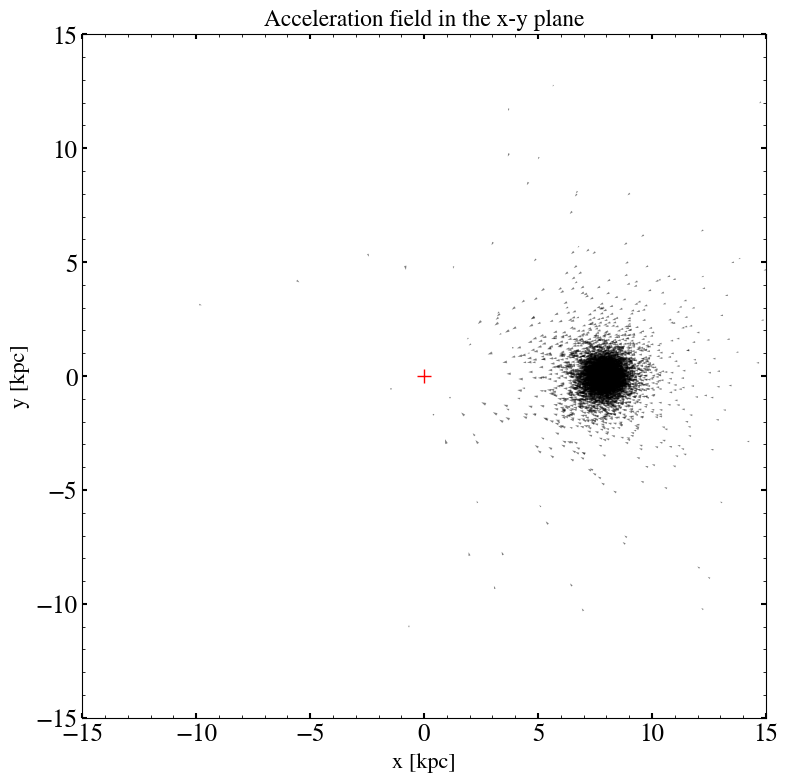

In [4]:
acc = sim.external_acc()

fig, ax = plt.subplots(figsize=(8, 8))
ax.quiver(pos[:, 0], pos[:, 1], acc[:, 0], acc[:, 1], alpha=0.5)
plt.plot(0, 0, color='r', marker='+', markersize=10, label='Host center')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_title('Acceleration field in the x-y plane')
ax.set_aspect('equal')
plt.tight_layout()
plt.xlim(-15, 15)
plt.ylim(-15, 15)

plt.show()

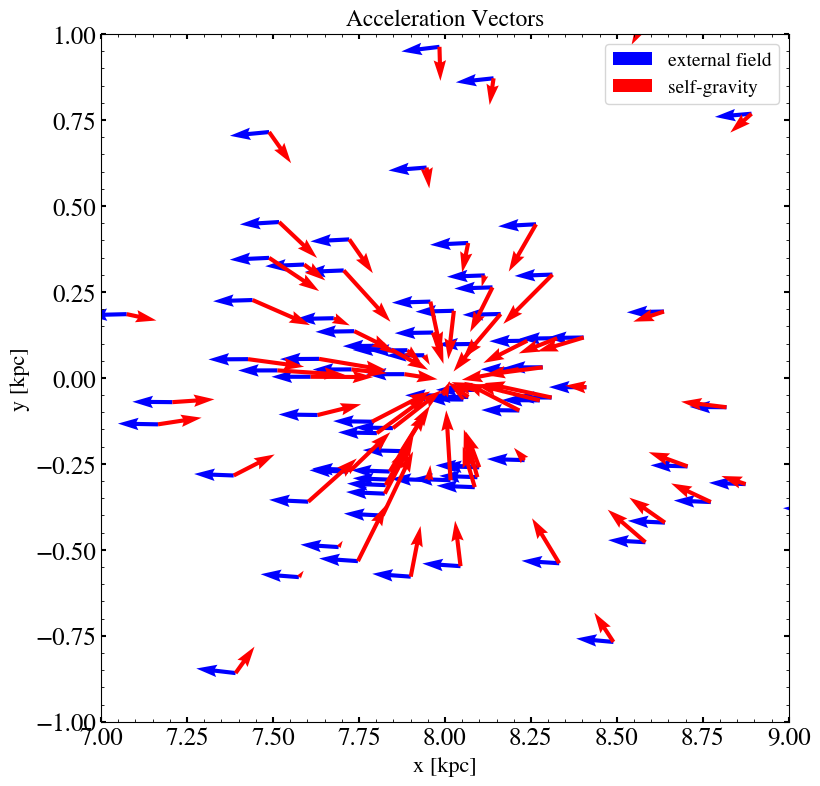

In [5]:
self_acc = sim.self_gravity(t=0, method='falcON',eps=0.1, theta=0.5)

fig, ax = plt.subplots(figsize=(8, 8))
ax.quiver(pos[:, 0][::100], pos[:, 1][::100], acc[:, 0][::100], acc[:, 1][::100], alpha=1, color='b', label='external field')
ax.quiver(pos[:, 0][::100], pos[:, 1][::100], self_acc[:, 0][::100], self_acc[:, 1][::100], alpha=1, color='r', label='self-gravity')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_title('Acceleration Vectors')
ax.set_aspect('equal')
plt.tight_layout()
plt.xlim(7, 9)
plt.ylim(-1, 1)
plt.legend()

plt.show()

In [6]:
sim.run(t_end=0.2, dt=0.0001, dt_out=0.002, eps=0.5, theta=0.6)

  0%|          | 0/2000 [00:00<?, ?it/s]

 14%|█▎        | 270/2000 [00:05<00:35, 48.96it/s]


KeyboardInterrupt: 

(-15.0, 15.0)

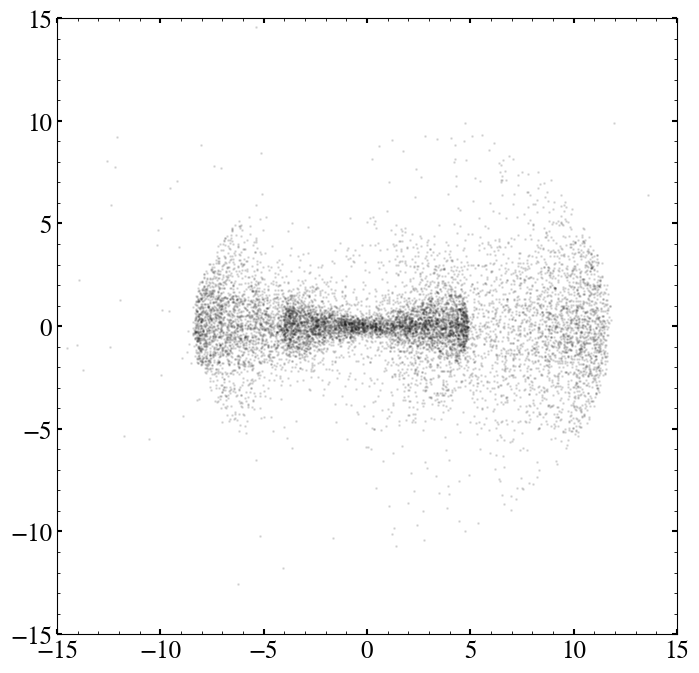

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(sim.x(-1), sim.y(-1), s=1, alpha=0.1, c='k')
plt.xlim(-15, 15)
plt.ylim(-15, 15)

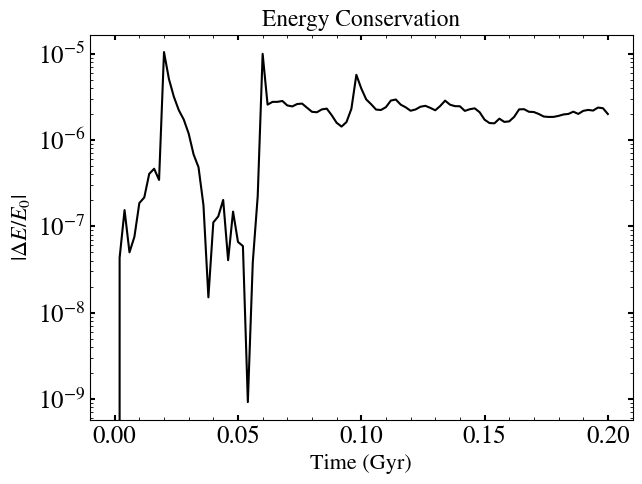

In [ ]:
sim.plot_energy_diagnostic()

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

n_frames = len(sim.x())//10

fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
sc = ax_anim.scatter(sim.x(0), sim.y(0), s=1, c='k', alpha=0.1)
ax_anim.plot(0, 0, 'r+', markersize=10, markeredgewidth=2)

ax_anim.set_xlim(-20, 20)
ax_anim.set_ylim(-20, 20)
ax_anim.set_xlabel('x [kpc]', fontsize=20)
ax_anim.set_ylabel('y [kpc]', fontsize=20)
title = ax_anim.set_title('t = 0', fontsize=22)

def update(i):
    i *= 10
    sc.set_offsets(list(zip(sim.x(i), sim.y(i))))
    title.set_text(f't = {sim.times[i]*1000 :.0f} Myr')
    return sc, title

anim = FuncAnimation(fig_anim, update, frames=n_frames, interval=50, blit=False)
fig_anim.tight_layout()
plt.close(fig_anim)
anim.save(
    'satellite_evolution.mp4',
    dpi=150,
    fps=20
)
# HTML(anim.to_jshtml())

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(



# Without Self-Gravity

In [ ]:
sim_ext_only = Sim()
sim_ext_only.add_particles('stars', pos, vel, masses)
sim_ext_only.add_external_pot(host_pot)
sim_ext_only.turn_self_gravity_off()
sim_ext_only.run(t_end=0.2, dt=0.0001, dt_out=0.002)

  2%|▏         | 49/2000 [00:00<00:04, 486.00it/s]

100%|██████████| 2000/2000 [00:04<00:00, 464.05it/s]


(-25.0, 25.0)

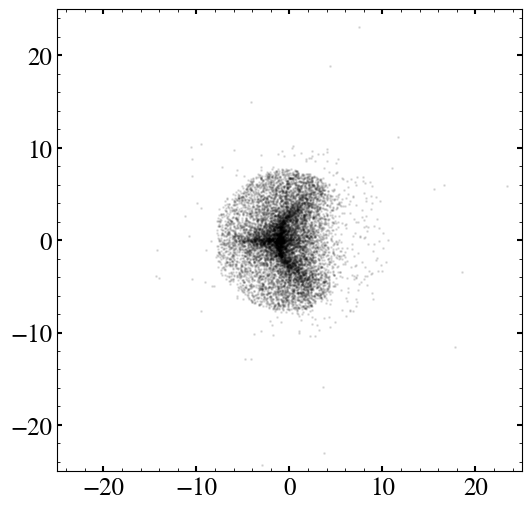

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(sim_ext_only.x(-1), sim_ext_only.y(-1), s=1, alpha=0.1, c='k')
plt.xlim(-25, 25)
plt.ylim(-25, 25)

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/simulation/simulation.py:1043: UserWarning: Computing external potential on-the-fly for multiple snapshots may be slow.
  warnings.warn("Computing external potential on-the-fly for multiple snapshots may be slow.")



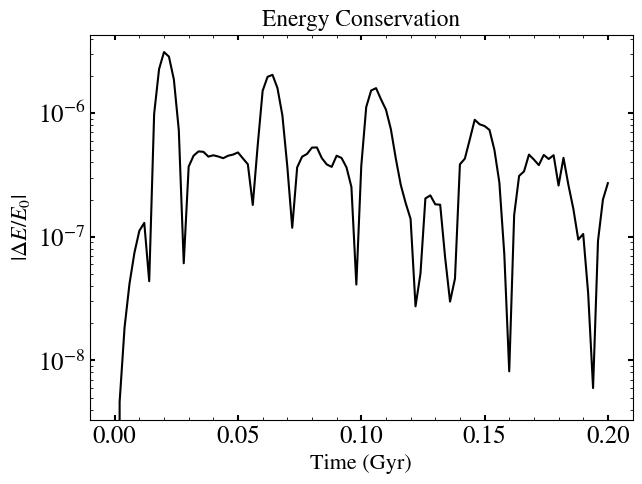

In [ ]:
sim_ext_only.plot_energy_diagnostic()

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

n_frames = len(sim.x())  # t_end=100, dt_out=10 -> snapshots at 0,10,...,100

fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
sc = ax_anim.scatter(sim_ext_only.x(0), sim_ext_only.y(0), s=1, c='k', alpha=0.1)
ax_anim.plot(0, 0, 'r+', markersize=10, markeredgewidth=2)

ax_anim.set_xlim(-20, 20)
ax_anim.set_ylim(-20, 20)
ax_anim.set_xlabel('x [kpc]')
ax_anim.set_ylabel('y [kpc]')
title = ax_anim.set_title('t = 0')

def update(i):
    sc.set_offsets(list(zip(sim_ext_only.x(i), sim_ext_only.y(i))))
    title.set_text(f't = {sim_ext_only.times[i]} Myr')
    return sc, title

anim = FuncAnimation(fig_anim, update, frames=n_frames, interval=50, blit=False)
plt.close(fig_anim)
# HTML(anim.to_jshtml())